In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image= cv2.imread('alpha_rise_oculus_raw_image-1764953518-592108253.png',  cv2.IMREAD_GRAYSCALE)
image = cv2.flip(image, -1)
image = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)

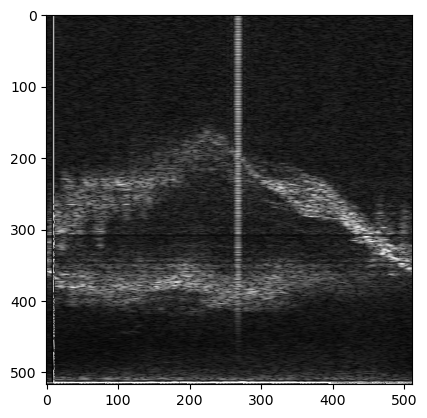

In [3]:
plt.imshow(image, cmap='gray')

In [4]:
import numpy as np
import cv2
from scipy.ndimage import generic_filter

def frost_filter_optimized(image, kernel_size=5, damping_factor=2.0):
    """
    Optimized Frost filter using vectorized operations.
    
    Parameters:
        image (np.ndarray): Grayscale image (uint8 or float32)
        kernel_size (int): Odd integer, size of local window
        damping_factor (float): Controls spatial decay
    
    Returns:
        np.ndarray: Filtered image
    """
    if kernel_size % 2 == 0:
        raise ValueError("kernel_size must be an odd number")

    image = image.astype(np.float32)

    pad = kernel_size // 2
    y, x = np.mgrid[-pad:pad+1, -pad:pad+1]
    distance_weight = np.exp(-damping_factor * np.sqrt(x**2 + y**2))
    
    def frost_func(window):
        window = window.reshape((kernel_size, kernel_size))
        local_mean = window.mean()
        local_var = window.var()
        
        if local_var == 0:
            return window[kernel_size//2, kernel_size//2]
        
        k = local_var / (local_mean**2 + 1e-6)
        w = distance_weight * np.exp(-k)
        w /= w.sum()
        return np.sum(w * window)
    
    filtered = generic_filter(image, frost_func, size=kernel_size, mode='reflect')
    return filtered.astype(np.uint8)


In [5]:
from scipy.ndimage import uniform_filter

def lee_filter(image, kernel_size=5):
    """
    Lee filter for speckle noise reduction.
    
    Parameters:
        image (np.ndarray): Grayscale image (uint8 or float)
        kernel_size (int): Odd window size
    
    Returns:
        np.ndarray: Filtered image
    """
    image = image.astype(np.float32)

    # Local mean
    local_mean = uniform_filter(image, kernel_size)

    # Local variance
    local_mean_sq = uniform_filter(image**2, kernel_size)
    local_var = local_mean_sq - local_mean**2

    # Estimate noise variance (global)
    noise_var = np.mean(local_var)

    # Lee filter
    weight = local_var / (local_var + noise_var)
    filtered = local_mean + weight * (image - local_mean)

    return np.clip(filtered, 0, 255).astype(np.uint8)

In [6]:
import numpy as np

def extract_all_points_in_sensor_frame(
    image,
    max_range=40.0,
    beam_skip_count=1,
    threshold_min_range=5.0,
    threshold_max_range=40.0,
    intensity_threshold=1,
    mode='all'
):
    """
    Convert pixels in the image into sensor-frame coordinates (x, y, intensity).
    """
    bearings=np.loadtxt("bearings.txt")
    bearings = np.array(bearings, dtype=np.float64).ravel()
    if image is None:
        raise ValueError("Image not found or unable to load.")

    # Coordinate grids
    rows, cols = np.indices(image.shape)
    n_bins = len(rows)
    range_factor = max_range / n_bins


    rows_flat = rows.ravel()
    cols_flat = cols.ravel()
    cols_flat = np.clip(cols_flat, 0, len(bearings)-1)
    intensities = image.ravel()

    # # 🔒 Safety check (critical)
    # if image.shape[1] != len(bearings):
    #     raise ValueError(
    #         f"Image columns ({image.shape[1]}) "
    #         f"do not match bearings length ({len(bearings)})"
    #     )

    theta_values = bearings[cols_flat]
    r_values = range_factor * (n_bins - rows_flat)

    # Sensor frame
    sensor_x = r_values * np.cos(theta_values)
    sensor_y = r_values * np.sin(theta_values)

    # Beam skipping
    indices = np.arange(len(sensor_x))
    mask_beam_skip = (indices % beam_skip_count) == 0

    # Range threshold
    distances = np.sqrt(sensor_x**2 + sensor_y**2)
    mask_range = (
        (distances > threshold_min_range) &
        (distances < threshold_max_range)
    )

    final_mask = mask_beam_skip & mask_range

    rows_flat = rows_flat[final_mask]
    cols_flat = cols_flat[final_mask]
    intensities = intensities[final_mask]
    sensor_x = sensor_x[final_mask]
    sensor_y = sensor_y[final_mask]

    # Intensity selection
    if mode == 'all':
        valid = intensities > intensity_threshold

    elif mode == 'max_intensity':
        valid = intensities > intensity_threshold
        rows_flat = rows_flat[valid]
        cols_flat = cols_flat[valid]
        intensities = intensities[valid]
        sensor_x = sensor_x[valid]
        sensor_y = sensor_y[valid]

        if len(intensities) == 0:
            return np.empty((0, 3)), np.empty((0, 3))

        # Max per column (fast & stable)
        idx = np.lexsort((-intensities, cols_flat))
        _, first_idx = np.unique(cols_flat[idx], return_index=True)
        keep = idx[first_idx]

        rows_flat = rows_flat[keep]
        cols_flat = cols_flat[keep]
        intensities = intensities[keep]
        sensor_x = sensor_x[keep]
        sensor_y = sensor_y[keep]

        valid = slice(None)

    else:
        raise ValueError("Invalid mode. Choose 'all' or 'max_intensity'.")

    rows_flat = rows_flat[valid]
    cols_flat = cols_flat[valid]
    intensities = intensities[valid]
    sensor_x = sensor_x[valid]
    sensor_y = sensor_y[valid]

    image_coordinates = np.column_stack((rows_flat, cols_flat, intensities))
    sensor_frame_coordinates = np.column_stack((sensor_x, sensor_y, intensities))
    image_out = np.zeros_like(image, dtype=image.dtype)
    image_out[rows_flat, cols_flat] = intensities

    return image_out


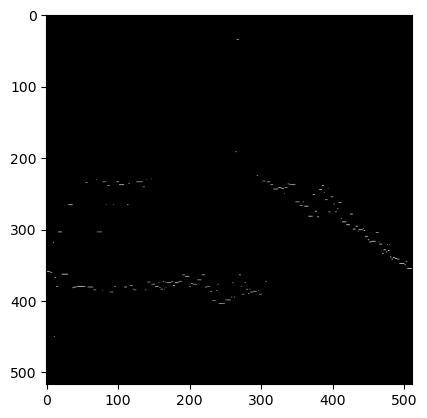

In [7]:
edge = extract_all_points_in_sensor_frame(image, mode="max_intensity")
plt.imshow(edge, cmap="gray")

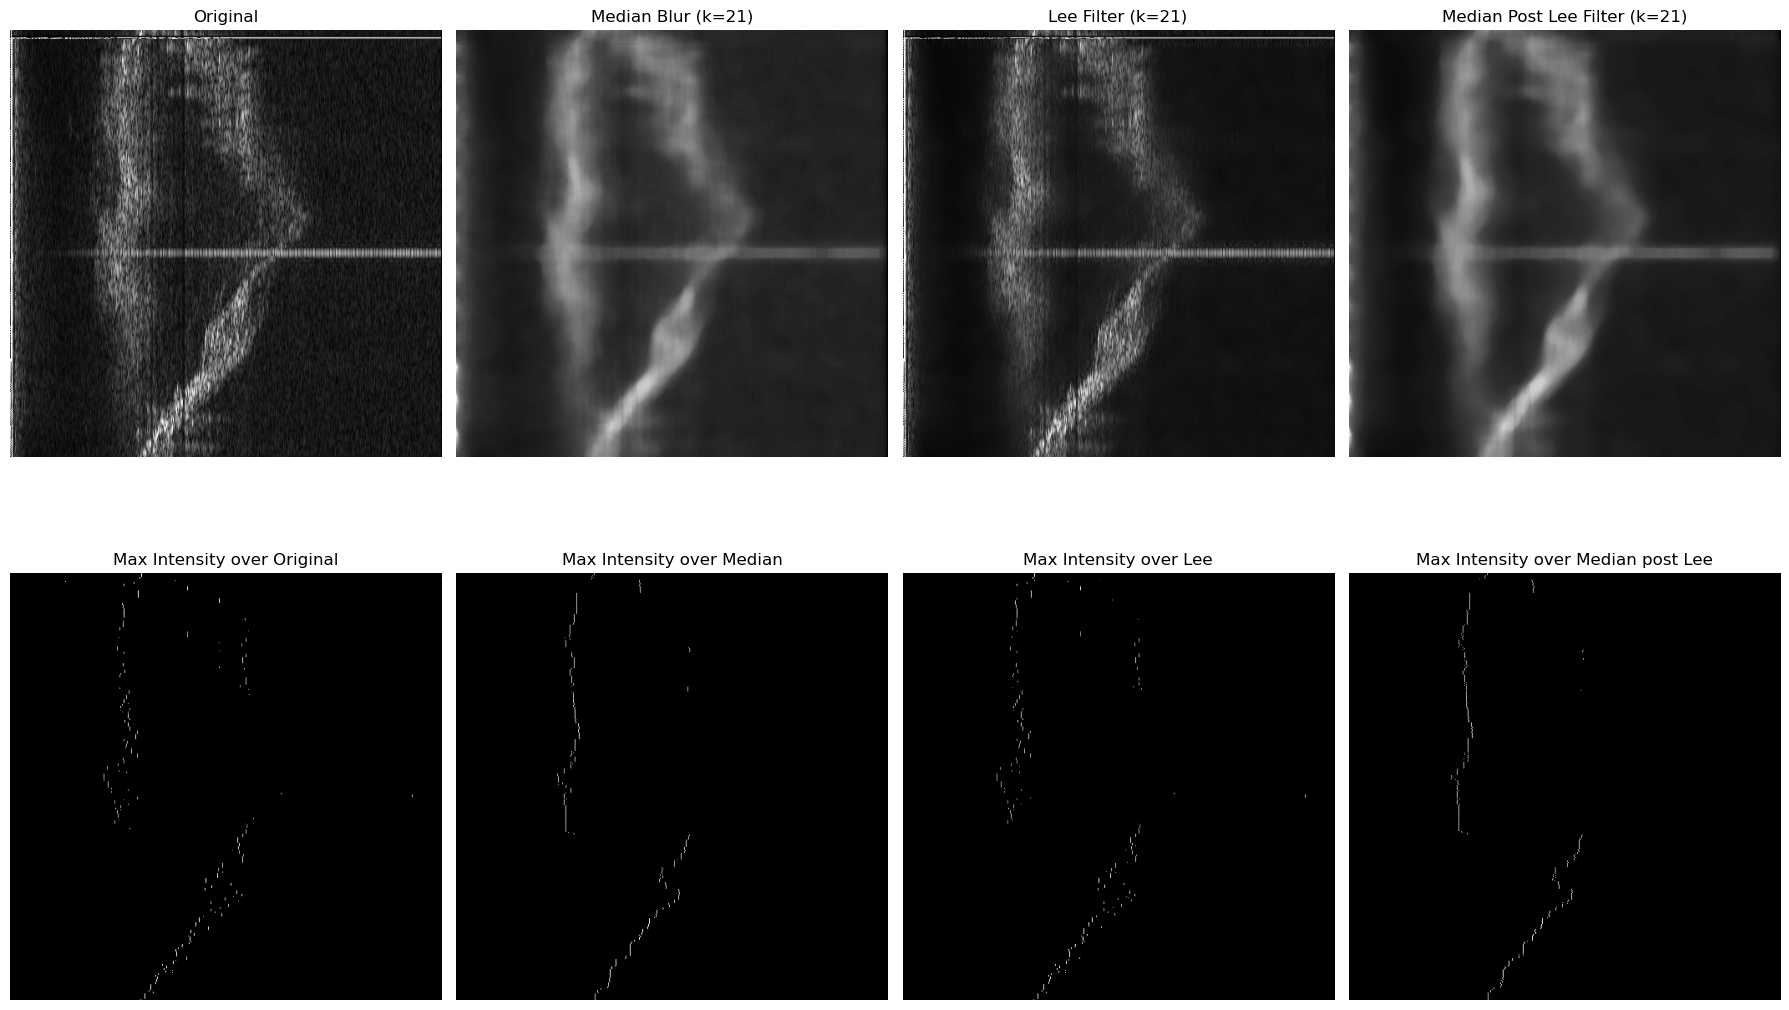

In [18]:
import matplotlib.pyplot as plt
import cv2

kernel = 21
lee = lee_filter(image, kernel_size=kernel)
median_post_lee = cv2.medianBlur(lee, kernel)
median = cv2.medianBlur(image, kernel)
edge_image = extract_all_points_in_sensor_frame(image, mode="max_intensity")
median_image = extract_all_points_in_sensor_frame(median, mode="max_intensity")
lee_image = extract_all_points_in_sensor_frame(lee, mode="max_intensity")
median_post_edge_lee = extract_all_points_in_sensor_frame(median_post_lee, mode="max_intensity")

# --- Flip horizontally and rotate 90° clockwise ---
def flip_rotate(img):
    # rotated = cv2.flip(img, 1)  # 1 = horizontal flip
    rotated = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    return rotated

image_viz = flip_rotate(image)
median_viz = flip_rotate(median)
median_post_lee = flip_rotate(median_post_lee)
lee_viz = flip_rotate(lee)
edge_viz = flip_rotate(edge_image)
median_edge_viz = flip_rotate(median_image)
median_post_lee_edge_viz = flip_rotate(median_post_edge_lee)

lee_edge_viz = flip_rotate(lee_image)

# 2 rows, 3 columns
fig, axes = plt.subplots(2, 4, figsize=(18, 12))

axes[0, 0].imshow(image_viz, cmap='gray')
axes[0, 0].set_title("Original")
axes[0, 0].axis('off')

axes[0, 1].imshow(median_viz, cmap='gray')
axes[0, 1].set_title(f"Median Blur (k={kernel})")
axes[0, 1].axis('off')

axes[0, 2].imshow(lee_viz, cmap='gray')
axes[0, 2].set_title(f"Lee Filter (k={kernel})")
axes[0, 2].axis('off')

axes[0, 3].imshow(median_post_lee, cmap='gray')
axes[0, 3].set_title(f"Median Post Lee Filter (k={kernel})")
axes[0, 3].axis('off')

axes[1, 0].imshow(edge_viz, cmap='gray')
axes[1, 0].set_title("Max Intensity over Original")
axes[1, 0].axis('off')

axes[1, 1].imshow(median_edge_viz, cmap='gray')
axes[1, 1].set_title("Max Intensity over Median")
axes[1, 1].axis('off')

axes[1, 2].imshow(lee_edge_viz, cmap='gray')
axes[1, 2].set_title("Max Intensity over Lee")
axes[1, 2].axis('off')


axes[1, 3].imshow(median_post_lee_edge_viz, cmap='gray')
axes[1, 3].set_title("Max Intensity over Median post Lee")
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()


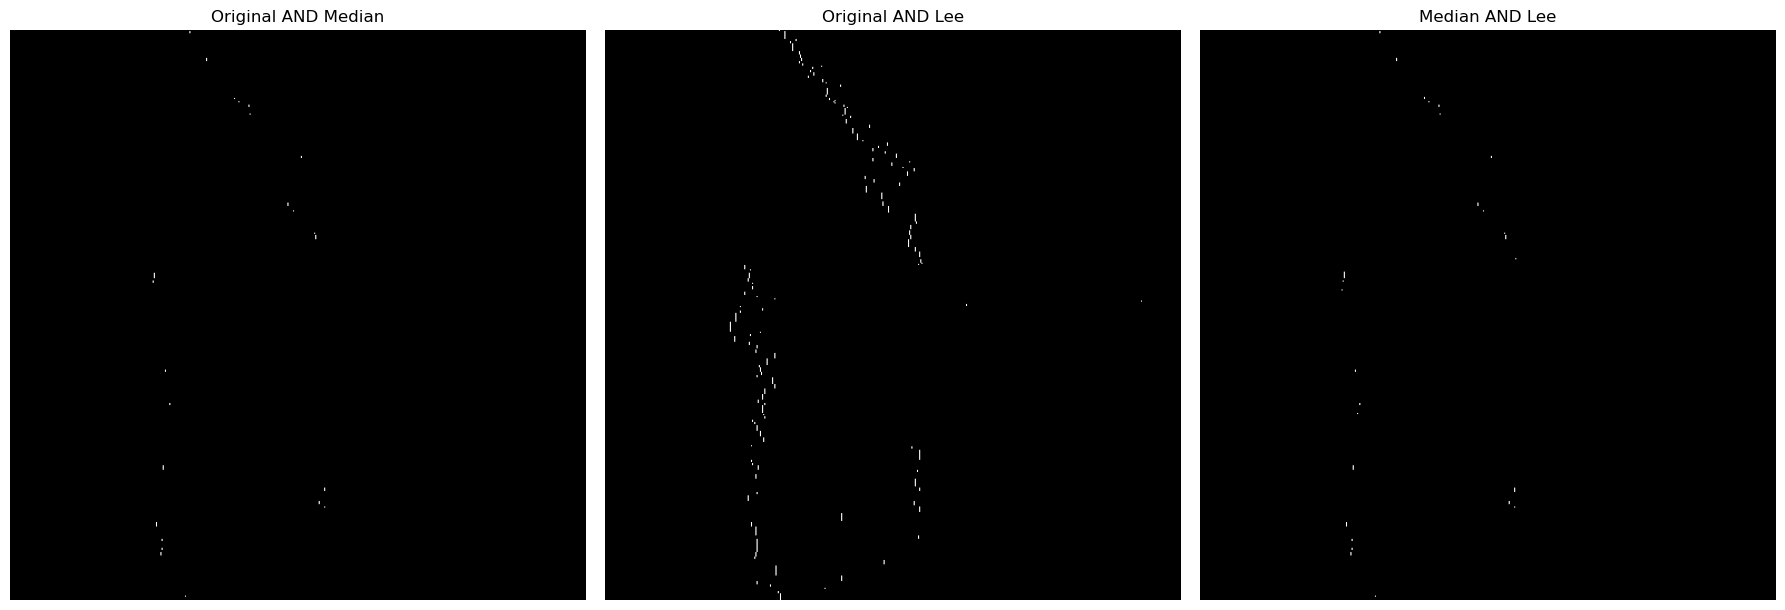

In [167]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Convert to binary masks
edge_mask = (edge_viz > 0).astype(np.uint8) * 255
median_mask = (median_edge_viz > 0).astype(np.uint8) * 255
lee_mask = (lee_edge_viz > 0).astype(np.uint8) * 255

# Compute pairwise AND masks
and_edge_median = cv2.bitwise_and(edge_mask, median_mask)
and_edge_lee = cv2.bitwise_and(edge_mask, lee_mask)
and_median_lee = cv2.bitwise_and(median_mask, lee_mask)

# Display in 1x3 grid
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(and_edge_median, cmap='gray')
axes[0].set_title("Original AND Median")
axes[0].axis('off')

axes[1].imshow(and_edge_lee, cmap='gray')
axes[1].set_title("Original AND Lee")
axes[1].axis('off')

axes[2].imshow(and_median_lee, cmap='gray')
axes[2].set_title("Median AND Lee")
axes[2].axis('off')

plt.tight_layout()
plt.show()
